# A/B Test Statistical Analysis
1) willingness
2) embarrassment
3) behavior (CTR and add-to-cart rate)

In [22]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

### Read Data

In [23]:
# 1. Read willingness.csv

w = pd.read_csv("willingness.csv", skiprows=1, header=None)

w = w.iloc[:, :3]
w.columns = ["ab_group", "score", "count"]

w = w[w["ab_group"].isin(["ab_A", "ab_B"])]

w["score"] = pd.to_numeric(w["score"], errors="coerce")
w["count"] = pd.to_numeric(w["count"], errors="coerce")

w = w.dropna()

w["score"] = w["score"].astype(int)
w["count"] = w["count"].astype(int)

print("=== Willingness table ===")
print(w)
print()


=== Willingness table ===
   ab_group  score  count
7      ab_B      4     19
8      ab_A      3     15
9      ab_B      3     14
10     ab_B      5     13
11     ab_A      2     13
12     ab_A      1     11
13     ab_B      2      9
14     ab_A      4      7
15     ab_B      1      6
16     ab_A      5      3



In [24]:
# 2. Read embarrassment.csv

e = pd.read_csv("embarrassment.csv", skiprows=1, header=None)

e = e.iloc[:, :3]
e.columns = ["ab_group", "score", "count"]

e = e[e["ab_group"].isin(["ab_A", "ab_B"])]

e["score"] = pd.to_numeric(e["score"], errors="coerce")
e["count"] = pd.to_numeric(e["count"], errors="coerce")

e = e.dropna()

e["score"] = e["score"].astype(int)
e["count"] = e["count"].astype(int)

print("=== Embarrassment table ===")
print(e)
print()

=== Embarrassment table ===
   ab_group  score  count
7      ab_B      1     26
8      ab_A      3     19
9      ab_B      2     15
10     ab_A      2     14
11     ab_B      3     13
12     ab_A      4      9
13     ab_A      5      9
14     ab_B      4      3
15     ab_A      1      1
16     ab_B      5      1



In [25]:
# 3. Read Behavior.csv

b = pd.read_csv("Behavior.csv", header=None)

print("=== Raw Behavior table ===")
print(b)
print()

row_B = b.iloc[3]
row_A = b.iloc[4]

A = {
    "impression": int(row_A[1]),
    "click": int(row_A[3]),
    "cart": int(row_A[5])
}

B = {
    "impression": int(row_B[1]),
    "click": int(row_B[3]),
    "cart": int(row_B[5])
}

print("=== Extracted Behavior Metrics ===")
print("A:", A)
print("B:", B)
print()

=== Raw Behavior table ===
            0                      1                      2                3  \
0  Event name  experiment_impression  experiment_impression  assistant_click   
1    ab group            Event count           Active users      Event count   
2         NaN                    232                     93              119   
3        ab_B                    123                     61               67   
4        ab_A                    109                     62               52   

                 4            5             6            7             8  \
0  assistant_click  add_to_cart   add_to_cart       Totals        Totals   
1     Active users  Event count  Active users  Event count  Active users   
2               70           50            32          401            93   
3               39           29            19          219            61   
4               31           21            13          182            62   

             9  
0          NaN  
1

In [26]:
# 4. Expand willingness / embarrassment from frequency table to raw samples

A_w = np.repeat(
    w[w["ab_group"] == "ab_A"]["score"],
    w[w["ab_group"] == "ab_A"]["count"]
)

B_w = np.repeat(
    w[w["ab_group"] == "ab_B"]["score"],
    w[w["ab_group"] == "ab_B"]["count"]
)

A_e = np.repeat(
    e[e["ab_group"] == "ab_A"]["score"],
    e[e["ab_group"] == "ab_A"]["count"]
)

B_e = np.repeat(
    e[e["ab_group"] == "ab_B"]["score"],
    e[e["ab_group"] == "ab_B"]["count"]
)

print("=== Sample sizes ===")
print("Willingness A:", len(A_w), "B:", len(B_w))
print("Embarrassment A:", len(A_e), "B:", len(B_e))
print()

=== Sample sizes ===
Willingness A: 49 B: 61
Embarrassment A: 52 B: 58



### Descriptive statistics

In [27]:
# 5. Descriptive statistics

print("=== Descriptive Statistics ===")

print("\nWillingness")
print("A mean:", np.mean(A_w))
print("B mean:", np.mean(B_w))
print("A std:", np.std(A_w, ddof=1))
print("B std:", np.std(B_w, ddof=1))
print("A median:", np.median(A_w))
print("B median:", np.median(B_w))

print("\nEmbarrassment")
print("A mean:", np.mean(A_e))
print("B mean:", np.mean(B_e))
print("A std:", np.std(A_e, ddof=1))
print("B std:", np.std(B_e, ddof=1))
print("A median:", np.median(A_e))
print("B median:", np.median(B_e))
print()

=== Descriptive Statistics ===

Willingness
A mean: 2.5510204081632653
B mean: 3.3934426229508197
A std: 1.1736911946539275
B std: 1.255370974713453
A median: 3.0
B median: 4.0

Embarrassment
A mean: 3.2115384615384617
B mean: 1.9310344827586208
A std: 1.0907191091029314
B std: 1.023617063909605
A median: 3.0
B median: 2.0



**Results:**

For willingness, Group B has a higher mean score (3.39) than Group A (2.55).  
For embarrassment, Group A has a higher mean score (3.21) than Group B (1.93).  

This suggests that users in Group B feel more willing to engage, while users in Group A experience higher embarrassment.

### T-test

In [28]:
# 6. Independent t-tests Use Welch's t-test (equal_var=False)

t_w, p_w = stats.ttest_ind(A_w, B_w, equal_var=False)
t_e, p_e = stats.ttest_ind(A_e, B_e, equal_var=False)

print("=== T-tests ===")
print("Willingness t-stat:", t_w)
print("Willingness p-value:", p_w)
print()

print("Embarrassment t-stat:", t_e)
print("Embarrassment p-value:", p_e)
print()

=== T-tests ===
Willingness t-stat: -3.626933394185542
Willingness p-value: 0.00044364386266994673

Embarrassment t-stat: 6.328311637374512
Embarrassment p-value: 6.230027274676217e-09



**Results:**

For willingness, the difference between Group A and Group B is statistically significant (p < 0.001).  

For embarrassment, the difference is also statistically significant (p < 0.001).  

This means that the observed differences in both willingness and embarrassment are unlikely to be due to random chance.

### Robustness Check

In [43]:
from scipy.stats import mannwhitneyu

# Willingness
u_w, p_u_w = mannwhitneyu(A_w, B_w, alternative="two-sided")

# Embarrassment
u_e, p_u_e = mannwhitneyu(A_e, B_e, alternative="two-sided")

print("=== Mann–Whitney U Test (Robustness Check) ===")
print("Willingness U:", u_w, "p:", p_u_w)
print("Embarrassment U:", u_e, "p:", p_u_e)
print()

=== Mann–Whitney U Test ===
Willingness U: 932.5 p: 0.0005447396885544625
Embarrassment U: 2401.5 p: 3.516401804935533e-08



**Robustness Check**

The Mann–Whitney U test confirms the same conclusions as the t-tests for both willingness and embarrassment (p < 0.001).  

This indicates that the results are robust and do not depend on normality assumptions.

### Effect size

In [29]:
# 7. Effect size: Cohen's d

# Willingness
mean_A_w = np.mean(A_w)
mean_B_w = np.mean(B_w)
var_A_w = np.var(A_w, ddof=1)
var_B_w = np.var(B_w, ddof=1)
pooled_sd_w = np.sqrt(((len(A_w)-1)*var_A_w + (len(B_w)-1)*var_B_w) / (len(A_w)+len(B_w)-2))
d_w = (mean_A_w - mean_B_w) / pooled_sd_w

# Embarrassment
mean_A_e = np.mean(A_e)
mean_B_e = np.mean(B_e)
var_A_e = np.var(A_e, ddof=1)
var_B_e = np.var(B_e, ddof=1)
pooled_sd_e = np.sqrt(((len(A_e)-1)*var_A_e + (len(B_e)-1)*var_B_e) / (len(A_e)+len(B_e)-2))
d_e = (mean_A_e - mean_B_e) / pooled_sd_e

print("=== Effect Size (Cohen's d) ===")
print("Willingness d:", d_w)
print("Embarrassment d:", d_e)
print()


=== Effect Size (Cohen's d) ===
Willingness d: -0.6906547643499089
Embarrassment d: 1.2127871582547063



**Effect Size Interpretation**

The effect size for willingness (Cohen’s d ≈ 0.69) indicates a moderate to large effect.  

For embarrassment, the effect size (Cohen’s d ≈ 1.21) is large, suggesting a strong practical impact of the treatment.

### Confidence Interval

In [36]:
from scipy import stats
import numpy as np
   
# ---- Willingness CI (B - A) ----
diff_w = np.mean(B_w) - np.mean(A_w)

se_w = np.sqrt(
    np.var(A_w, ddof=1)/len(A_w) +
    np.var(B_w, ddof=1)/len(B_w)
)

df_w = (se_w**4) / (
    ((np.var(A_w, ddof=1)/len(A_w))**2)/(len(A_w)-1) +
    ((np.var(B_w, ddof=1)/len(B_w))**2)/(len(B_w)-1)
)

t_crit_w = stats.t.ppf(0.975, df_w)

ci_w = (diff_w - t_crit_w*se_w, diff_w + t_crit_w*se_w)

print("=== 95% CI (Willingness, B - A) ===")
print("Difference:", diff_w)
print("CI:", ci_w)
print()


# ---- Embarrassment CI (A - B) ----
diff_e = np.mean(A_e) - np.mean(B_e)

se_e = np.sqrt(
    np.var(A_e, ddof=1)/len(A_e) +
    np.var(B_e, ddof=1)/len(B_e)
)

df_e = (se_e**4) / (
    ((np.var(A_e, ddof=1)/len(A_e))**2)/(len(A_e)-1) +
    ((np.var(B_e, ddof=1)/len(B_e))**2)/(len(B_e)-1)
)

t_crit_e = stats.t.ppf(0.975, df_e)

ci_e = (diff_e - t_crit_e*se_e, diff_e + t_crit_e*se_e)

print("=== 95% CI (Embarrassment, A - B) ===")
print("Difference:", diff_e)
print("CI:", ci_e)
print()

=== 95% CI (Willingness, B - A) ===
Difference: 0.8424222147875544
CI: (np.float64(0.3819016467663671), np.float64(1.3029427828087417))

=== 95% CI (Embarrassment, A - B) ===
Difference: 1.280503978779841
CI: (np.float64(0.8792839126835291), np.float64(1.6817240448761526))



**Confidence Intervals**

The 95% confidence interval for willingness (B − A) is entirely above zero, indicating that Group B consistently performs better.  

Similarly, the confidence interval for embarrassment (A − B) is also entirely above zero, confirming that Group A experiences higher embarrassment.  

These intervals provide additional evidence supporting the statistical significance of the results.

### Behavior metrics: CTR and Cart rate

In [30]:
# 8. Behavior metrics: CTR and Cart rate

A_ctr = A["click"] / A["impression"]
B_ctr = B["click"] / B["impression"]

A_cart_rate = A["cart"] / A["impression"]
B_cart_rate = B["cart"] / B["impression"]

print("=== Behavior Rates ===")
print("CTR A:", A_ctr)
print("CTR B:", B_ctr)
print()

print("Cart rate A:", A_cart_rate)
print("Cart rate B:", B_cart_rate)
print()

=== Behavior Rates ===
CTR A: 0.47706422018348627
CTR B: 0.5447154471544715

Cart rate A: 0.1926605504587156
Cart rate B: 0.23577235772357724



**Results:**

Group B shows higher CTR (0.545 vs. 0.477) and higher add-to-cart rate (0.236 vs. 0.193).  

However, the proportion z-tests indicate that these differences are not statistically significant (p > 0.05).

Although the behavioral differences are not statistically significant, both CTR and add-to-cart rate consistently favor Group B. This suggests that the treatment may already be influencing user decision-making, but the effect size is relatively small. Combined with the low statistical power, this indicates that the experiment may be underpowered rather than ineffective. It is also possible that behavioral actions require stronger or repeated exposure to translate psychological improvements into observable actions. 


### Proportion z-tests

In [31]:
# 9. Proportion z-tests

# CTR
count_ctr = np.array([A["click"], B["click"]])
nobs_ctr = np.array([A["impression"], B["impression"]])
z_ctr, p_ctr = proportions_ztest(count_ctr, nobs_ctr)

# Cart
count_cart = np.array([A["cart"], B["cart"]])
nobs_cart = np.array([A["impression"], B["impression"]])
z_cart, p_cart = proportions_ztest(count_cart, nobs_cart)

print("=== Proportion Z-tests ===")
print("CTR z-stat:", z_ctr)
print("CTR p-value:", p_ctr)
print()

print("Cart z-stat:", z_cart)
print("Cart p-value:", p_cart)
print()


=== Proportion Z-tests ===
CTR z-stat: -1.0288990645615317
CTR p-value: 0.303527108005628

Cart z-stat: -0.797049566687681
Cart p-value: 0.4254222449107481



### Summary

In [32]:
# 10. Build clean summary tables

survey_results = pd.DataFrame({
    "Metric": ["Willingness", "Embarrassment"],
    "Mean_A": [np.mean(A_w), np.mean(A_e)],
    "Mean_B": [np.mean(B_w), np.mean(B_e)],
    "Std_A": [np.std(A_w, ddof=1), np.std(A_e, ddof=1)],
    "Std_B": [np.std(B_w, ddof=1), np.std(B_e, ddof=1)],
    "N_A": [len(A_w), len(A_e)],
    "N_B": [len(B_w), len(B_e)],
    "Test_Statistic": [t_w, t_e],
    "P_Value": [p_w, p_e],
    "Cohens_d": [d_w, d_e]
})

behavior_results = pd.DataFrame({
    "Metric": ["CTR", "Add-to-Cart Rate"],
    "Rate_A": [A_ctr, A_cart_rate],
    "Rate_B": [B_ctr, B_cart_rate],
    "Success_A": [A["click"], A["cart"]],
    "Success_B": [B["click"], B["cart"]],
    "Total_A": [A["impression"], A["impression"]],
    "Total_B": [B["impression"], B["impression"]],
    "Z_Statistic": [z_ctr, z_cart],
    "P_Value": [p_ctr, p_cart]
})

print("=== Survey Results Table ===")
print(survey_results)
print()

print("=== Behavior Results Table ===")
print(behavior_results)
print()


=== Survey Results Table ===
          Metric    Mean_A    Mean_B     Std_A     Std_B  N_A  N_B  \
0    Willingness  2.551020  3.393443  1.173691  1.255371   49   61   
1  Embarrassment  3.211538  1.931034  1.090719  1.023617   52   58   

   Test_Statistic       P_Value  Cohens_d  
0       -3.626933  4.436439e-04 -0.690655  
1        6.328312  6.230027e-09  1.212787  

=== Behavior Results Table ===
             Metric    Rate_A    Rate_B  Success_A  Success_B  Total_A  \
0               CTR  0.477064  0.544715         52         67      109   
1  Add-to-Cart Rate  0.192661  0.235772         21         29      109   

   Total_B  Z_Statistic   P_Value  
0      123    -1.028899  0.303527  
1      123    -0.797050  0.425422  



In [33]:
survey_results.to_csv("survey_results_summary.csv", index=False)
behavior_results.to_csv("behavior_results_summary.csv", index=False)

print("Saved:")
print("- survey_results_summary.csv")
print("- behavior_results_summary.csv")
print()

Saved:
- survey_results_summary.csv
- behavior_results_summary.csv



### Power Analysis

In [37]:
# Power Analysis

from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()

# CTR effect size
effect_size_ctr = abs(B_ctr - A_ctr)

power_ctr = analysis.power(
    effect_size=effect_size_ctr,
    nobs1=A["impression"],
    ratio=B["impression"]/A["impression"],
    alpha=0.05
)

print("=== Power Analysis (CTR) ===")
print("Effect size:", effect_size_ctr)
print("Estimated power:", power_ctr)

=== Power Analysis (CTR) ===
Effect size: 0.06765122697098525
Estimated power: 0.08080854415217985


**Power Analysis**

The estimated statistical power for CTR is very low (around 0.08), which is far below the recommended level of 0.80.  

This suggests that the experiment may not have enough data to detect meaningful differences in behavior.  

Therefore, the lack of statistical significance in behavioral metrics may be due to insufficient sample size rather than the absence of a real effect.

This highlights an important experimental limitation: failing to detect significance does not imply no effect, but rather insufficient evidence due to limited sample size. Increasing sample size would be necessary to draw definitive conclusions about behavioral impact.

### Funnel Interpretation

In [38]:
# Funnel Interpretation

print("\n=== Funnel Analysis ===")

print("A click → cart conversion:", A["cart"]/A["click"])
print("B click → cart conversion:", B["cart"]/B["click"])


=== Funnel Analysis ===
A click → cart conversion: 0.40384615384615385
B click → cart conversion: 0.43283582089552236


**Funnel Interpretation**

This suggests that the treatment not only increases initial engagement (CTR), but may also improve deeper-stage conversion efficiency. The consistency across multiple funnel stages indicates that the treatment effect is not isolated but may influence the entire user journey.

### Willingness Distribution

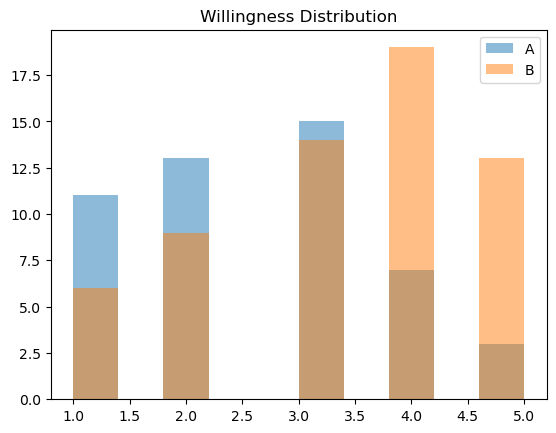

In [39]:
import matplotlib.pyplot as plt

plt.hist(A_w, alpha=0.5, label="A")
plt.hist(B_w, alpha=0.5, label="B")
plt.legend()
plt.title("Willingness Distribution")
plt.show()

### Correlation

In [40]:
# Correlation

all_scores = pd.DataFrame({
    "willingness": np.concatenate([A_w, B_w]),
    "embarrassment": np.concatenate([A_e, B_e])
})

corr = all_scores.corr()
print(corr)

               willingness  embarrassment
willingness       1.000000      -0.180127
embarrassment    -0.180127       1.000000


**Cross-Metric Insight**

This negative correlation suggests a potential psychological mechanism underlying the treatment effect: reducing embarrassment may directly increase users’ willingness to engage. This provides a coherent explanation for why Group B improves perception metrics and shows consistent (though not significant) improvements in behavioral outcomes.

**Overall Insight**

The experiment shows a clear psychological effect but a weaker behavioral effect.  

Group B significantly improves willingness and reduces embarrassment, indicating a better user experience.  

However, these improvements do not translate into statistically significant changes in behavior, likely due to low statistical power.  

This suggests that the treatment is effective in shaping user perception, and further data collection may reveal stronger behavioral impacts.

### Conclusion

Overall, treatment B demonstrates a clear and consistent advantage over treatment A from a user experience perspective. The statistical analysis shows that users in Group B report significantly higher willingness and significantly lower embarrassment, with strong statistical significance, robust test results, and large effect sizes, indicating that the treatment meaningfully improves user perception at a psychological level. Although behavioral metrics such as CTR and add-to-cart rate are not statistically significant, they consistently favor Group B in magnitude; combined with the low statistical power, this suggests that the current experiment may not have sufficient sample size to detect modest but real behavioral effects, rather than indicating the absence of an effect. Importantly, the results across metrics are directionally consistent: reduced embarrassment is associated with increased willingness, which aligns with the observed improvements in engagement and conversion trends, suggesting a plausible mechanism where improved user comfort leads to higher readiness to act and may eventually translate into measurable behavioral gains. In conclusion, treatment B is a promising design that significantly enhances user perception and shows early signals of behavioral improvement, and future experiments with larger samples are recommended to validate its impact on downstream user actions.